<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/Forecasing_Future_Sales_using_ARIMA_and_SARIMAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ARIMA and Seasonal ARIMA**

Autoregressive Integrated Moving Averages

The general process for ARIMA models is the following:

*   Visualize the Time Series Data
*   Make the time series data stationary
*   Plot the Correlation and AutoCorrection charts
*   Contrus the ARIMA Model or Seasonal ARIMA based on the data
*   Use the model to make predictions



In [43]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv('/content/perrin-freres-monthly-champagne-.csv')

In [6]:
df.head()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [7]:
df.tail()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0
105,NaN,NaN
106,Perrin Freres monthly champagne sales millions...,NaN


In [8]:
## Cleaning up the data
df.columns = ['Month', 'Sales']
df.head()

,Month,Sales
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [9]:
##Drop last 2 rows
df.drop(106 , axis = 0, inplace = True)
df.drop(105 , axis = 0, inplace = True)

In [10]:
df.tail()

,Month,Sales
100,1972-05,4618.0
101,1972-06,5312.0
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0


In [11]:
#Convert Month into Datetime
df['Month'] = pd.to_datetime(df['Month'])

In [12]:
df.head(14)

,Month,Sales
0,1964-01-01,2815.0
1,1964-02-01,2672.0
2,1964-03-01,2755.0
3,1964-04-01,2721.0
4,1964-05-01,2946.0
5,1964-06-01,3036.0
6,1964-07-01,2282.0
7,1964-08-01,2212.0
8,1964-09-01,2922.0
9,1964-10-01,4301.0


In [13]:
df.set_index('Month', inplace = True)

In [14]:
df.head(14)

,Sales
Month,
1964-01-01,2815.0
1964-02-01,2672.0
1964-03-01,2755.0
1964-04-01,2721.0
1964-05-01,2946.0
1964-06-01,3036.0
1964-07-01,2282.0
1964-08-01,2212.0
1964-09-01,2922.0


In [15]:
df.describe()

,Sales
count,105.000000
mean,4761.152381
std,2553.502601
min,1413.000000
25%,3113.000000
50%,4217.000000
75%,5221.000000
max,13916.000000


**Step 2 : Visualize the Data**

<Axes: xlabel='Month'>

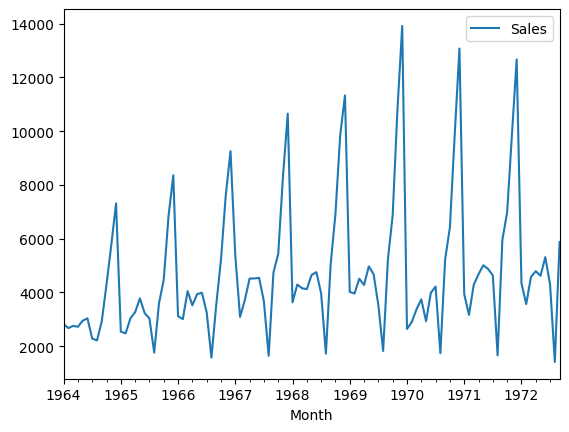

In [16]:
df.plot()

In [17]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

In [18]:
test_data = adfuller(df['Sales'])
test_data

print("ADF Statistics = ",test_data[0])
print("P Value = ", test_data[1])
print("Number of Lags = ", test_data[2])
print("Number of Observations = ", test_data[3])
print("Critical Values = ", test_data[4])

ADF Statistics =  -1.8335930563276215
P Value =  0.36391577166024586
Number of Lags =  11
Number of Observations =  93
Critical Values =  {'1%': np.float64(-3.502704609582561), '5%': np.float64(-2.8931578098779522), '10%': np.float64(-2.583636712914788)}


In [19]:
#HO : It is non stationarity
#H1 : It is Stationary

def adfuller_test(sales):

  result = adfuller(sales)
  labels = ['ADF Test Statistics', 'p-value', '#lags Used', 'Number of Observations Used']

  for value,label in zip (result, labels):
    print(label+ ' : ' + str(value) )
  if result[1] <= 0.05:
    print("Strong evidence against the null hypothesis(HO), reject the null hypothesis")

  else:
    print("weak evidence against null hypothesis,  time series has a unit root, indicating it is non stationary")

In [20]:
adfuller_test(df['Sales'])

ADF Test Statistics : -1.8335930563276215
p-value : 0.36391577166024586
#lags Used : 11
Number of Observations Used : 93
weak evidence against null hypothesis,  time series has a unit root, indicating it is non stationary


**Differencing**

Next step is differencing

You should now apply first-order differencing:

In [21]:
df['sales First Difference'] = df['Sales'] - df['Sales'].shift(1)

In [22]:
df['Seasonal First Difference'] = df['Sales'] - df['Sales'].shift(12)

In [23]:
df.head(14)

,Sales,sales First Difference,Seasonal First Difference
Month,,,
1964-01-01,2815.0,NaN,NaN
1964-02-01,2672.0,-143.0,NaN
1964-03-01,2755.0,83.0,NaN
1964-04-01,2721.0,-34.0,NaN
1964-05-01,2946.0,225.0,NaN
1964-06-01,3036.0,90.0,NaN
1964-07-01,2282.0,-754.0,NaN
1964-08-01,2212.0,-70.0,NaN
1964-09-01,2922.0,710.0,NaN


In [24]:
adfuller_test(df['Seasonal First Difference'].dropna())

ADF Test Statistics : -7.626619157213166
p-value : 2.0605796968136632e-11
#lags Used : 0
Number of Observations Used : 92
Strong evidence against the null hypothesis(HO), reject the null hypothesis


<Axes: xlabel='Month'>

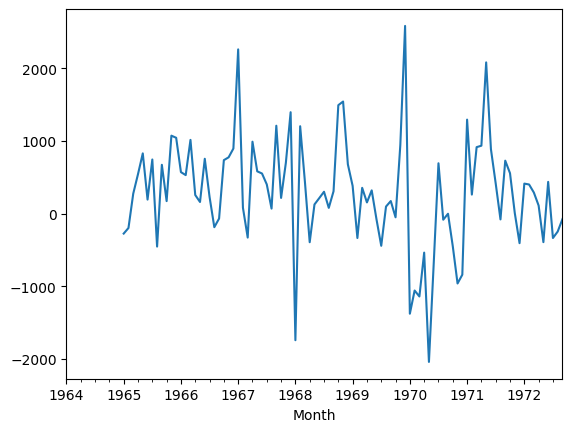

In [25]:
df['Seasonal First Difference'].plot()

**AR I MA**
#####AR = Auto Regresssive model
#####I = integrated ( differencing)
#####MA = Moving Averages

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

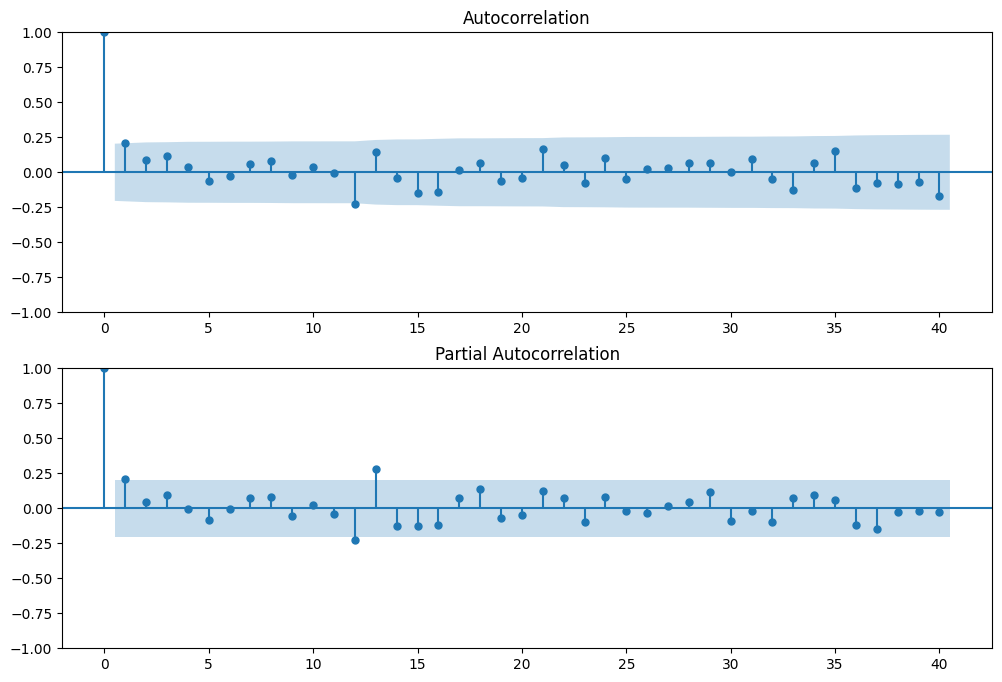

In [33]:
import statsmodels.api as sm

fig = plt.figure(figsize = (12,8))

ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Seasonal First Difference'].iloc[13:],lags =40, ax = ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Seasonal First Difference'].iloc[13:],lags =40, ax = ax2)

In [ ]:
import statsmodels.api as sm
model = sm.tsa.ARIMA(df['Sales'], order = (2,1,2))
model_fit = model.fit()

In [36]:
#For non seasonal data

from statsmodels.tsa.arima_model import ARIMA

In [37]:

model = ARIMA(df['Sales'], order = (1,1,1))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [38]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                  105
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -952.814
Date:                Tue, 19 May 2026   AIC                           1911.627
Time:                        21:52:53   BIC                           1919.560
Sample:                    01-01-1964   HQIC                          1914.841
                         - 09-01-1972                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4545      0.114      4.000      0.000       0.232       0.677
ma.L1         -0.9666      0.056    -17.319      0.000      -1.076      -0.857
sigma2      5.226e+06   6.17e+05      8.473      0.000    4.02e+06    6.43e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.91   Jarque-Bera (JB):                 2.59
Prob(Q):                              0.34   Prob(JB):                         0.27
Heteroskedasticity (H):               3.40   Skew:                             0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
import statsmodels.api as sm

In [39]:
model = sm.tsa.statespace.SARIMAX(df['Sales'],order = (1,1,1),seasonal_order=(1,1,1,12))
results = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='Month'>

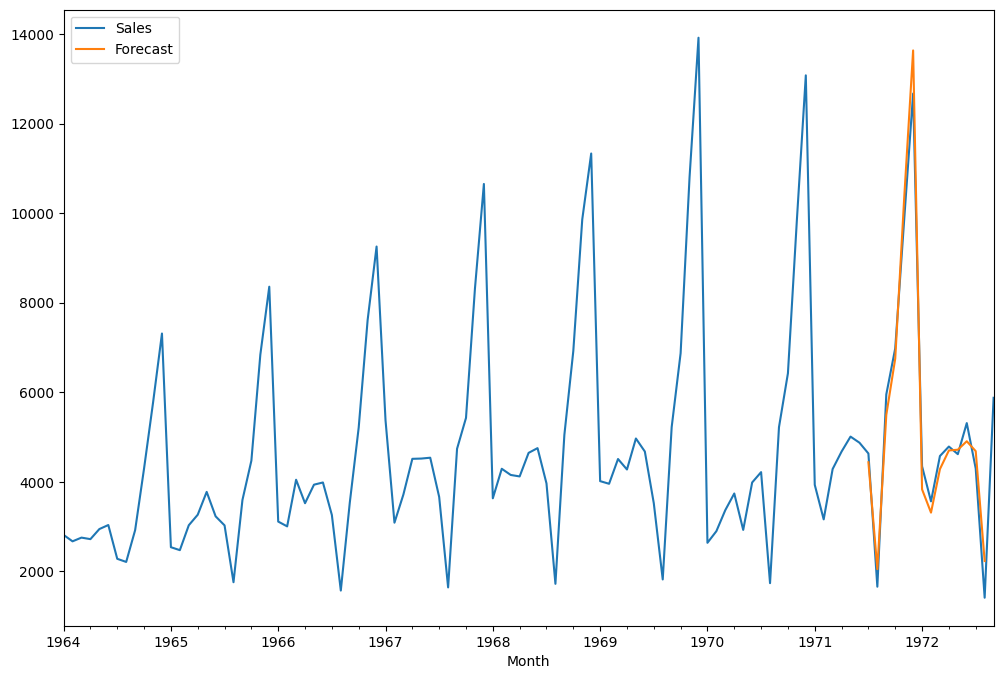

In [42]:
df['Forecast'] = results.predict(start = 90, end = 103,dynamic = True)
df[['Sales', 'Forecast']].plot(figsize = (12,8))

In [48]:
from pandas.tseries.offsets import DateOffset

In [49]:
future_dates = [df.index[-1]+ DateOffset(months = x) for x in range(0,24)]

In [50]:
future_dates_df = pd.DataFrame(index = future_dates[1:], columns = df.columns)

In [51]:
future_dates_df.tail()

,Sales,sales First Difference,Seasonal First Difference,Forecast
1974-04-01,NaN,NaN,NaN,NaN
1974-05-01,NaN,NaN,NaN,NaN
1974-06-01,NaN,NaN,NaN,NaN
1974-07-01,NaN,NaN,NaN,NaN
1974-08-01,NaN,NaN,NaN,NaN


In [52]:
future_df = pd.concat([df,future_dates_df])

/tmp/ipykernel_31392/4136492854.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  future_df = pd.concat([df,future_dates_df])


<Axes: >

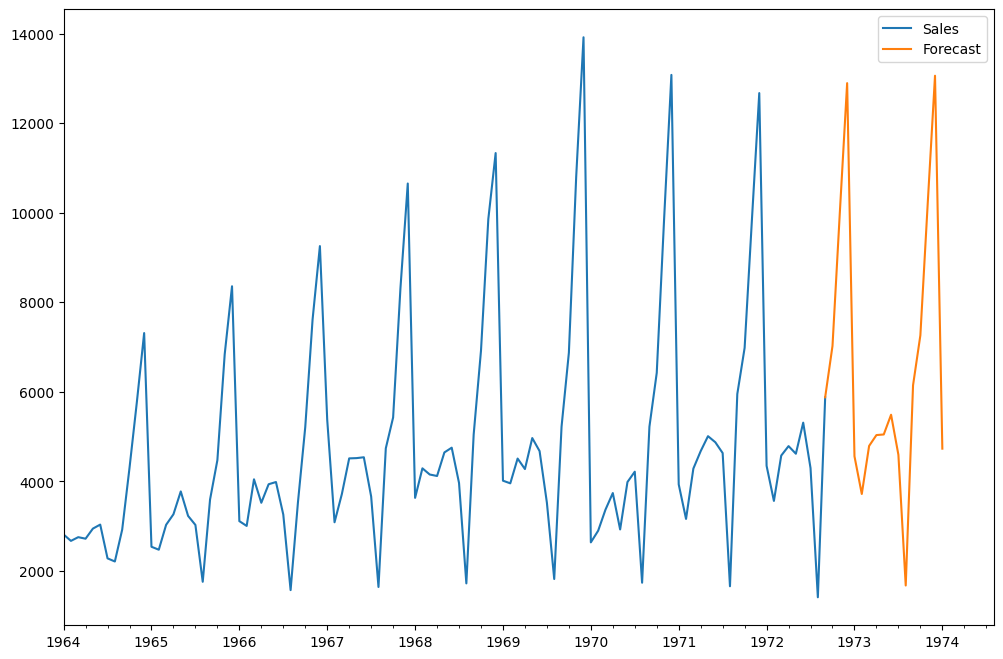

In [53]:
future_df['Forecast'] = results.predict(start = 104, end = 120, dynamic = True)
future_df [['Sales', 'Forecast']].plot(figsize = (12,8))